In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "src/qudits_on_qubits").is_dir())
for path in (ROOT, ROOT / "src"):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))
from scripts.iqm_bell_short import build_catalog, select_layout, make_plan, execute, read_samples, analyze, write_json
from qudits_on_qubits.benchmarks.direct_basis.iqm_backend import load_iqm_backend

In [2]:
DEVICE = "emerald"
REPEATS = 32
SHOTS = 128
SEED = 20260910
RUN_HARDWARE = False
SCALES = (1, 1.5, 2, 2.5, 3)
CAMPAIGN = ROOT / "artifacts/iqm_bell_short/emerald_20260910_5scales"

(CVXPY) Sep 11 10:20:59 AM: Encountered unexpected exception importing solver MPAX:
ImportError('DLL load failed while importing _jax: Procedura inicjowania biblioteki dołączanej dynamicznie (DLL) nie powiodła się.')


,setting,CZ,r,depth
0,A0 / B0,6,14,12
1,A0 / B1,9,22,12
2,A0 / B2,9,22,12
3,A1 / B0,6,14,12
4,A1 / B1,9,22,12
5,A1 / B2,9,22,12
6,A2 / B0,6,14,12
7,A2 / B1,9,22,12
8,A2 / B2,9,22,12


Bell ideal: 6.000000000000005
Shots per setting and scale: 4096
Total shots: 405504


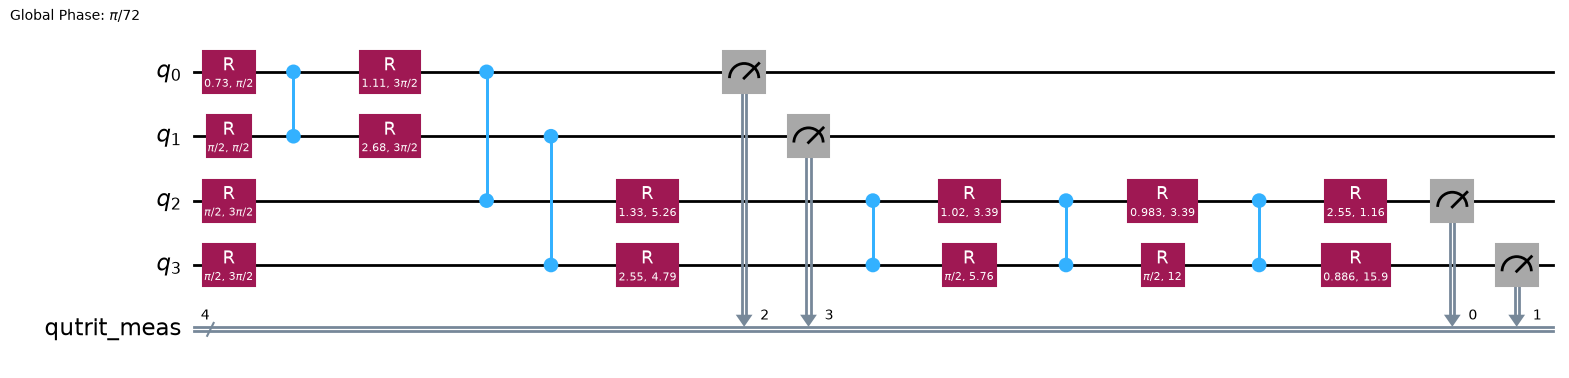

In [3]:
circuits, weights, evidence = build_catalog(ROOT)
display(pd.DataFrame([dict(setting=" / ".join(s), CZ=c.count_ops()["cz"], r=c.count_ops()["r"], depth=c.depth()) for s, c in zip(evidence["settings"], circuits)]))
print("Bell ideal:", evidence["ideal_bell"])
print("Shots per setting and scale:", REPEATS * SHOTS)
print("Total shots:", (1 + 2 * len(SCALES)) * 9 * REPEATS * SHOTS)
circuits[0].draw("mpl", fold=100)

In [4]:
if RUN_HARDWARE:
    backend = load_iqm_backend(DEVICE, use_metrics=True)
    physical_circuits, selection = select_layout(circuits, backend)
    display(pd.DataFrame(selection["metrics"]))
    print("Layout:", selection["layout"], "Candidates:", selection["candidates"])
    print("Calibration:", selection["calibration_set_id"])
    plan = make_plan(physical_circuits, repeats=REPEATS, shots=SHOTS, seed=SEED, scales=SCALES)
    display(pd.DataFrame([dict(arm=j["arm"], circuits=len(j["circuits"]), shots=j["shots"], DD=j["dd"]) for j in plan]))

In [5]:
if RUN_HARDWARE:
    RUN_HARDWARE = False
    samples = execute(CAMPAIGN, plan, backend, selection, allow_hardware=True)
    write_json(CAMPAIGN / "circuit_evidence.json", evidence)
    np.save(CAMPAIGN / "bell_weights.npy", weights, allow_pickle=False)

,variant,bell,standard_error,ci95_low,ci95_high,leakage,shots
0,RAW,5.434576,0.037314,5.346342,5.522810,0.031467,36864
1,DD,5.470950,0.035510,5.386982,5.554917,0.032308,36864
2,TWIRLING,5.317828,0.036172,5.232296,5.403361,0.033420,36864
3,DD + ZNE,5.665400,0.047932,5.552059,5.778742,NaN,184320
4,TWIRLING + ZNE,5.529466,0.048311,5.415228,5.643703,NaN,184320


,scales,values,curvature,curvature_standard_error,linear_model_warning
DD,"[1, 1.5, 2, 2.5, 3]","[5.47094994242577, 5.175607174071565, 5.159231...",0.204066,0.097102,False
TWIRLING,"[1, 1.5, 2, 2.5, 3]","[5.317828471585512, 5.158641934948065, 5.05188...",0.066727,0.126981,False


95% Student-t intervals across interleaved blocks of 4 repeats with a shot-noise floor; excludes ZNE model bias and arbitrary drift


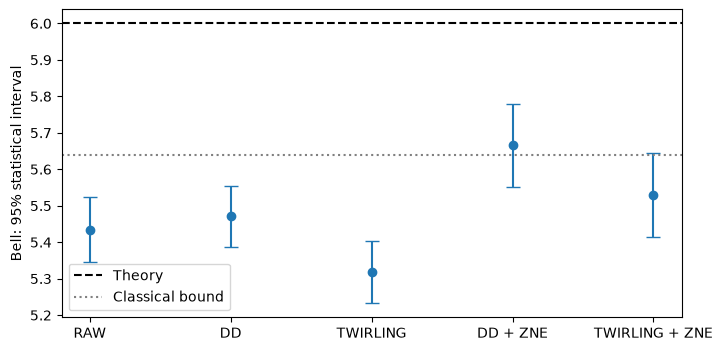

In [6]:
if (CAMPAIGN / "manifest.json").exists():
    samples = read_samples(CAMPAIGN)
    result = analyze(samples, weights, scales=SCALES)
    write_json(CAMPAIGN / "analysis.json", result)
    table = pd.DataFrame(result["rows"])
    display(table)
    display(pd.DataFrame(result["fits"]).T)
    print(result["uncertainty"])
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.errorbar(table["variant"], table["bell"], yerr=[table["bell"]-table["ci95_low"], table["ci95_high"]-table["bell"]], fmt="o", capsize=5)
    ax.axhline(evidence["ideal_bell"], color="black", linestyle="--", label="Theory")
    ax.axhline(evidence["classical_bound"], color="grey", linestyle=":", label="Classical bound")
    ax.set_ylabel("Bell: 95% statistical interval")
    ax.legend()
    plt.show()

,arm,model,bell_zero,ci95_low,ci95_high,residual_dof,failed_draws,status,decaying_to_finite_offset
0,DD,linear,5.665400,5.540260,5.789229,3,0,ok,None
1,DD,quadratic,6.022515,5.587487,6.460036,2,0,ok,None
2,DD,exponential,5.694016,5.556848,5.829213,3,0,ok,None
3,DD,exponential_offset,6.341082,NaN,NaN,2,14,unstable,True
4,TWIRLING,linear,5.529466,5.409531,5.651113,3,0,ok,None
5,TWIRLING,quadratic,5.646239,5.127380,6.122830,2,0,ok,None
6,TWIRLING,exponential,5.549823,5.423727,5.679997,3,0,ok,None
7,TWIRLING,exponential_offset,5.675605,NaN,NaN,2,1,unstable,True


linear: a + b*s; quadratic: a + b*s + c*s**2; exponential: A*exp(-k*s); exponential_offset: c + A*exp(-k*s)
Ordinary least squares on Bell values; approximate 95% intervals from joint multivariate Student-t propagation across interleaved repeat blocks, with a covariance floor from shot noise. Intervals exclude model bias. No interval is reported when any uncertainty draw cannot be fitted.
A model with as many parameters as scales interpolates and cannot be validated by its residuals.
An exponential with a free offset may have no finite large-scale asymptote.
Offset exponential fits with more than three points search rates with abs(k) * (max_scale - min_scale) <= 20 and reject singular or boundary solutions.
Intermediate scales average partial folds; nonlinear noise scaling is a model assumption.
With 5 scales, polynomials of degree >= 5 are not uniquely determined; adding a * product(x - scale) leaves measured points unchanged.


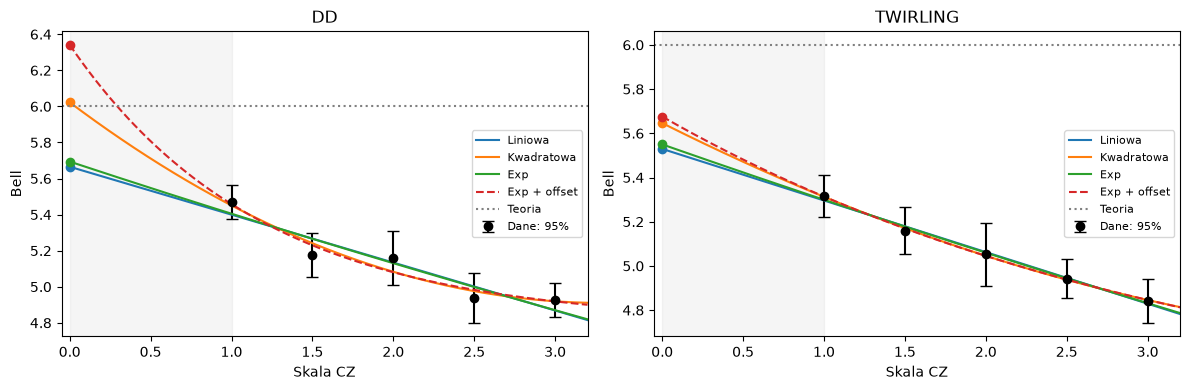

In [7]:
from scripts.iqm_bell_zne_models import compare_models, plot_comparison
if (CAMPAIGN / "bell_weights.npy").exists():
    model_comparison = compare_models(read_samples(CAMPAIGN), np.load(CAMPAIGN / "bell_weights.npy", allow_pickle=False), seed=SEED, scales=SCALES)
    write_json(CAMPAIGN / "model_comparison.json", model_comparison)
    display(pd.DataFrame(model_comparison["rows"])[["arm", "model", "bell_zero", "ci95_low", "ci95_high", "residual_dof", "failed_draws", "status", "decaying_to_finite_offset"]])
    print("linear: a + b*s; quadratic: a + b*s + c*s**2; exponential: A*exp(-k*s); exponential_offset: c + A*exp(-k*s)")
    print(model_comparison["method"])
    for warning in model_comparison["warnings"]:
        print(warning)
    print(model_comparison["unidentified_polynomials"]["reason"])
    fig = plot_comparison(model_comparison)
    fig.savefig(CAMPAIGN / "zne_model_comparison.png", dpi=180, bbox_inches="tight")
    plt.show()


In [8]:
from scripts.iqm_bell_zne_models import campaign_statistics, compare_statistics
if (CAMPAIGN / "bell_weights.npy").exists():
    statistics = campaign_statistics(read_samples(CAMPAIGN), np.load(CAMPAIGN / "bell_weights.npy", allow_pickle=False), scales=SCALES)
    indices = [0, 2, 4]
    subset = {arm: dict(blocks=v["blocks"][:, indices], shot_covariance=v["shot_covariance"][np.ix_(indices, indices)], scales=[1, 2, 3], repeats_per_block=4) for arm, v in statistics.items()}
    three_scale_comparison = compare_statistics(subset, seed=SEED)
    write_json(CAMPAIGN / "three_scale_subset_comparison.json", three_scale_comparison)
    comparison = pd.DataFrame(model_comparison["rows"]).merge(pd.DataFrame(three_scale_comparison["rows"]), on=["arm", "model"], suffixes=("_five", "_three"))
    comparison["width95_three"] = comparison["ci95_high_three"] - comparison["ci95_low_three"]
    comparison["width95_five"] = comparison["ci95_high_five"] - comparison["ci95_low_five"]
    comparison["width_reduction_percent"] = 100 * (1 - comparison["width95_five"] / comparison["width95_three"])
    display(comparison[["arm", "model", "bell_zero_three", "bell_zero_five", "width95_three", "width95_five", "width_reduction_percent"]])
    comparison.to_csv(CAMPAIGN / "scale_comparison.csv", index=False)


,arm,model,bell_zero_three,bell_zero_five,width95_three,width95_five,width_reduction_percent
0,DD,linear,5.731266,5.665400,0.274566,0.248969,9.322639
1,DD,quadratic,5.859773,6.022515,1.075262,0.872549,18.852356
2,DD,exponential,5.757232,5.694016,0.294464,0.272365,7.504912
3,DD,exponential_offset,5.885113,6.341082,NaN,NaN,NaN
4,TWIRLING,linear,5.545979,5.529466,0.253988,0.241582,4.884834
5,TWIRLING,quadratic,5.640450,5.646239,1.230532,0.995451,19.104053
6,TWIRLING,exponential,5.565836,5.549823,0.274701,0.256270,6.709250
7,TWIRLING,exponential_offset,5.655804,5.675605,NaN,NaN,NaN
